
# 🚀 Day 40 — Recurrent Neural Networks (RNN)

## From Sequence Modeling Foundations to Hands-On RNN Implementation

---

# 📌 What You’ll Learn

- Why ANN fails for sequential data
- Sequential data & temporal dependency
- RNN architecture
- Hidden states & memory
- Forward propagation in RNN
- Backpropagation Through Time (BPTT)
- Vanishing & exploding gradients
- Types of RNN architectures
- Bidirectional RNN
- Deep/Stacked RNN
- Hands-on sentiment classification using RNN

---

# 🎯 Real-World Applications

- Chatbots
- Speech Recognition
- Time Series Forecasting
- Language Translation
- Text Generation
- Sentiment Analysis


# 📘 Introduction to RNN


Recurrent Neural Networks (RNNs) are neural networks specially designed for sequential data.

Traditional neural networks process inputs independently.
RNNs introduce memory through hidden states.

The core idea:

> Current prediction depends on current input + previous context.

Examples:
- Text
- Audio
- Video frames
- Time series
- Sensor data


# 📘 Why ANN Fails for Sequential Data


ANNs assume all inputs are independent.

Problems:
- No memory
- Cannot understand order
- Cannot capture temporal relationships

Example:
- “Dog bites man”
- “Man bites dog”

Same words.
Different meaning.
ANN cannot naturally understand this.


# 📘 Sequential Data & Temporal Dependency


Sequential data means order matters.

Temporal dependency:
Current information depends on previous information.

Examples:
- Next word prediction
- Speech recognition
- Weather forecasting
- Stock price prediction


# 📘 RNN Architecture


Basic RNN Components:
1. Input
2. Hidden State
3. Output
4. Recurrent Connection

The hidden state acts like memory.


# 📘 Hidden States & Memory Mechanism


Hidden state stores information from previous timesteps.

Example:
Sentence:
“The movie was not good.”

While processing “good”, the model should remember “not”.


# 📘 Unrolling RNN Through Time


RNN can be visualized as multiple copies across timesteps.

Each timestep:
- receives input
- updates hidden state
- generates output

Same weights are reused across time.


# 📘 Weight Sharing in RNN


RNN uses the same weights at every timestep.

Benefits:
- Fewer parameters
- Better generalization
- Efficient learning


# 📘 Forward Propagation in RNN


At every timestep:

1. Receive input
2. Combine with previous hidden state
3. Generate new hidden state
4. Produce output


# 📘 Backpropagation Through Time (BPTT)


RNN training uses Backpropagation Through Time.

Gradients flow backward across:
- layers
- timesteps

This allows learning from sequence context.


# 📘 Vanishing Gradient Problem


Repeated multiplication of small gradients causes gradients to shrink.

Result:
- Early timesteps learn very slowly
- Long-term memory is lost


# 📘 Exploding Gradient Problem


Gradients become extremely large.

Results:
- Unstable learning
- Huge weight updates
- Diverging training

Solution:
Gradient Clipping


# 📘 Long-Term Dependency Problem


Basic RNN struggles with long sequences.

Example:
“I grew up in France ... therefore I speak fluent French.”

Model may forget “France”.


# 📘 Activation Functions in RNN


Tanh:
- Range [-1, 1]
- Most common hidden activation

Sigmoid:
- Range [0, 1]
- Used in gating mechanisms


# 📘 Types of RNN Architectures


One-to-One:
- Image Classification

One-to-Many:
- Image Captioning

Many-to-One:
- Sentiment Analysis

Many-to-Many:
- Machine Translation


# 📘 Bidirectional RNN


BiRNN processes sequence:
- Forward direction
- Backward direction

Allows understanding from past + future context.


# 📘 Deep / Stacked RNN


Multiple RNN layers stacked together.

Benefits:
- Richer feature extraction
- Better sequence understanding

Drawback:
- Computationally expensive



# 🧪 Hands-On Project — Sentiment Analysis using Simple RNN

## Goal
Build an RNN model that predicts whether a movie review is:
- Positive
- Negative

We will use:
- TensorFlow / Keras
- IMDB Dataset


## 🔹 Install Libraries

In [ ]:

# Uncomment if needed
# !pip install tensorflow


## 🔹 Import Libraries

In [1]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


## 🔹 Load Dataset

In [2]:

vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training Samples: 25000
Testing Samples: 25000


## 🔹 Pad Sequences

In [3]:

max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print(X_train.shape)
print(X_test.shape)


(25000, 200)
(25000, 200)


## 🔹 Build RNN Model

In [4]:

model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model.summary()


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 🔹 Compile Model

In [5]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


## 🔹 Train Model

In [6]:

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.6761 - loss: 0.5787 - val_accuracy: 0.7834 - val_loss: 0.4707
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.8166 - loss: 0.4118 - val_accuracy: 0.7996 - val_loss: 0.4547
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.9305 - loss: 0.1846 - val_accuracy: 0.8136 - val_loss: 0.4982
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.9773 - loss: 0.0720 - val_accuracy: 0.8110 - val_loss: 0.6070
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.9890 - loss: 0.0364 - val_accuracy: 0.7960 - val_loss: 0.6977


## 🔹 Evaluate Model

In [7]:

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7820 - loss: 0.7315
Test Loss: 0.731465756893158
Test Accuracy: 0.782039999961853


## 🔹 Plot Accuracy

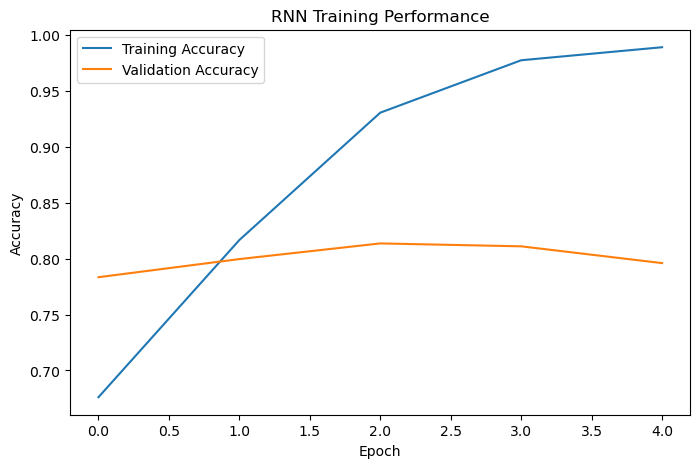

In [8]:

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training Performance")
plt.legend()

plt.show()


## 🔹 Prediction Example

In [14]:

sample = X_test[21].reshape(1, -1)

prediction = model.predict(sample)

print("Prediction Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Positive Review")
else:
    print("Negative Review")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction Score: 0.99842435
Positive Review


## 🔹 Experiment Ideas

In [ ]:

# Try these experiments:
# 1. Increase RNN units
# 2. Add another RNN layer
# 3. Replace SimpleRNN with LSTM
# 4. Replace SimpleRNN with GRU
# 5. Use Bidirectional RNN



# 🎯 Key Takeaways

- RNNs introduced memory into neural networks
- Hidden states preserve sequence information
- RNNs work well for sequential data
- Vanilla RNN struggles with long-term dependencies
- LSTM and GRU were introduced to solve RNN limitations
- RNNs became the foundation for modern NLP evolution

---

# 🚀 Next Step

Continue with:
- LSTM
- GRU
- Seq2Seq
- Attention Mechanism
- Transformers
